Import libraries. Will probably have to install prophet first.

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error

sns.set_style("whitegrid")

Load Dataset and run generic clean.

In [ ]:
file_path = ""
time_power_df = pd.read_csv(file_path)
solar_system = Clean(2105, "")
#add_features(self, data, daily_lags, include_last_year, days_rolling_average_exact, todays_lags, include_month, include_hour, sunlight_duration)
system_df = solar_system.add_features(time_power_df, 0, False, 0, 0, False, True, False) #<-- TO DO: Figure out features


Clean data, and sort by date. In order to use Prophet, the columns need to be labelled ds (for datestamp) and y (for target).

In [ ]:
system_df = system_df.sort_values("time")
system_df = system_df.rename(columns={"time": "ds", "power": "y"})

Function to add sunlight duration to future dataframe.

In [ ]:
def future_sunlight_duration(date):
    if system_df[system_df['ds'] == date].empty:
        pass #TO DO: <-- Past the times in system_df; I need to pull the sunlight_duration from OpenMeteo
    else:
        #If the time appears in system_df, then we can pull sunlight duration from there.
        return system_df[system_df['ds'] == date]['sunlight_duration']


Make train/test split, and then make forecast.

In [ ]:
mapes = []
forecasts = []

for i, date in enumerate(pd.date_range('2021–01–01', '2021–12–31', freq='H')): #<-- TO DO: Figure out date range
    #Make the rolling window split
    next_day = date + pd.offsets.Day(1)
    train = system_df.loc[date - pd.offsets.Day(14):date]
    test = system_df.loc[date:next_day] #<-- need to adjust to avoid overlap at boundary
    
    #Fit Prophet model. Here, daily and yearly seasonal components are enabled.
    model = Prophet(daily_seasonality=True, yearly_seasonality=True) #<-- TO DO: Explore hyperparameters
    model.add_regressor('sunlight_duration') #<-- system_df must have "sunlight_duration" as a column
    model.fit(train) 

    #Forecast future values. Number of hours predicted is represented by periods argument.
    #The forecast will return columns yhat (predicted value), yhat_lower, yhat_upper.
    future = model.make_future_dataframe(periods=24, freq='H', include_history=True)
    
    #In order for Prophet to make a forecast, we need to have sunshine_duration data for the forecast window.
    #We will call a sunshine_duration() function that adds this data to the future dataframe.
    future['sunlight_duration'] = future['ds'].apply(future_sunlight_duration) #<-- get next_day's sunshine duration from system_df
    forecasts[i] = model.predict(future)

    #Compare forecasted values to actual values, and compute MAPE.
    merged = pd.merge(test, (forecasts[i])[["ds", "yhat"]], on="ds", how="inner")

    if not merged.empty:
        mapes[i] = mean_absolute_percentage_error(merged["y"], merged["yhat"]) * 100
        

Make forecast if we have a generic kfold split function (no hyperparameter tuning.)

In [ ]:
mapes = []
forecasts = []

kfold = TimeSplit(n_splits = 5, test_size = 24) #<-- TO DO: Rewrite for whatever our split function is
for i, (train_index, test_index) in enumerate(kfold.split(system_df)):
    #Fit Prophet model. Here, daily and yearly seasonal components are enabled.
    model = Prophet(daily_seasonality=True, yearly_seasonality=True) #<-- TO DO: Explore hyperparameters
    model.add_regressor('sunlight_duration') #<-- system_df must have "sunlight_duration" as a column
    model.fit(train_index) #<-- Not sure if this will just be an index or a dataframe

    #Forecast future values. Number of hours predicted is represented by periods argument.
    #The forecast will return columns yhat (predicted value), yhat_lower, yhat_upper.
    future = model.make_future_dataframe(periods=24, freq='H', include_history=True)
    
    #In order for Prophet to make a forecast, we need to have sunshine_duration data for the forecast window.
    #We will call a sunshine_duration() function that adds this data to the future dataframe.
    future['sunlight_duration'] = future['ds'].apply(future_sunlight_duration) #<-- get next_day's sunshine duration from system_df
    forecasts[i] = model.predict(future)

    #Compare forecasted values to actual values, and compute MAPE.
    merged = pd.merge(test_index, (forecasts[i])[["ds", "yhat"]], on="ds", how="inner")

    if not merged.empty:
        mapes[i] = mean_absolute_percentage_error(merged["y"], merged["yhat"]) * 100


Make forecast if we have a generic kfold split function and are tuning hyperparameters (using nested cross-validation).

In [ ]:
mapes = []
forecasts = []

kfold = TimeSplit(n_splits = 5, test_size = 24) #<-- TO DO: Rewrite for whatever our split function is
for train_index, test_index in kfold.split(system_df):
    #Fit Prophet model. Here, daily and yearly seasonal components are enabled.
    model = Prophet(daily_seasonality=True, yearly_seasonality=True) #<-- TO DO: Explore hyperparameters
    model.add_regressor('sunlight_duration') #<-- system_df must have "sunlight_duration" as a column
    model.fit(train_index) #<-- Not sure if this will just be an index or a dataframe

    #Forecast future values. Number of hours predicted is represented by periods argument.
    #The forecast will return columns yhat (predicted value), yhat_lower, yhat_upper.
    future = model.make_future_dataframe(periods=24, freq='H', include_history=True)
    
    #In order for Prophet to make a forecast, we need to have sunshine_duration data for the forecast window.
    #We will call a sunshine_duration() function that adds this data to the future dataframe.
    future['sunlight_duration'] = future['ds'].apply(future_sunlight_duration) #<-- get next_day's sunshine duration from system_df
    forecasts[i] = model.predict(future)

    #Compare forecasted values to actual values, and compute MAPE.
    merged = pd.merge(test_index, (forecasts[i])[["ds", "yhat"]], on="ds", how="inner")

    if not merged.empty:
        mapes[i] = mean_absolute_percentage_error(merged["y"], merged["yhat"]) * 100
        
# 2) Nested CV
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
nested_scores = []
inner_cv_scores = []


for train_idx, test_idx in outer_cv.split(X):
    X_outer_train, X_outer_test = X[train_idx], X[test_idx]
    y_outer_train, y_outer_test = y[train_idx], y[test_idx]
    
    # Inner CV for hyperparameter tuning
    inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)
    inner_search = RandomizedSearchCV(
        RandomForestClassifier(random_state=42),
        param_distributions,
        n_iter=200,
        cv=inner_cv,
        scoring='accuracy',
        random_state=42,
        n_jobs=-1
    )
    inner_search.fit(X_outer_train, y_outer_train)

    inner_cv_scores.append(float(inner_search.best_score_))

    
    # Evaluate best model on outer test fold
    best_inner_model = clone(inner_search.best_estimator_)
    best_inner_model.fit(X_outer_train, y_outer_train)
    acc = accuracy_score(y_outer_test, best_inner_model.predict(X_outer_test))
    nested_scores.append(acc)

print("\nNested CV (unbiased estimate):")
print("Inner fold accuracies:", inner_cv_scores)
print("Outer fold accuracies:", nested_scores)
print("Mean Accuracy:", np.mean(nested_scores))


Plot the forecasts.

In [ ]:
for i in forecasts:
    fig1 = model.plot(forecasts[i])
    plt.title("Gold Futures (GC00) - Close Price Forecast")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.show()

Plot seasonal components (trend, weekly, yearly, daily)

In [ ]:
for i in forecasts:
    fig2 = model.plot_components(forecasts[i])
    plt.show()

Review forecast samples.

In [ ]:
for i in forecasts:
    print(forecasts[i][["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(10))

### Testing

In [39]:
# 1. Create a date range (e.g., 5 years of daily data)
dates = pd.date_range(start='2021-01-01', periods=1826, freq='D')

# 2. Generate synthetic components
t = np.arange(len(dates))
trend = 0.5 * t                              # Linear upward trend
yearly = 10 * np.sin(2 * np.pi * t / 365.25) # Yearly seasonality
weekly = 5 * np.sin(2 * np.pi * t / 7)      # Weekly seasonality
noise = np.random.normal(0, 2, len(dates))   # Random noise

# 3. Combine components into the target variable 'y'
y = 100 + trend + yearly + weekly + noise

# 4. Create the Prophet-ready DataFrames with train/test split
df = pd.DataFrame({'ds': dates, 'y': y})

#train: 4 yrs test: 1 yr
end_date = pd.to_datetime('2024-12-31')
mask1 = (df['ds'] <= end_date)
mask2 = (df['ds'] > end_date)

df_tr = df.loc[mask1]
df_tst = df.loc[mask2]

23:23:24 - cmdstanpy - INFO - Chain [1] start processing
23:23:25 - cmdstanpy - INFO - Chain [1] done processing


  0%|          | 0/15 [00:00<?, ?it/s]

23:23:25 - cmdstanpy - INFO - Chain [1] start processing
23:23:26 - cmdstanpy - INFO - Chain [1] done processing
23:23:26 - cmdstanpy - INFO - Chain [1] start processing
23:23:26 - cmdstanpy - INFO - Chain [1] done processing
23:23:26 - cmdstanpy - INFO - Chain [1] start processing
23:23:27 - cmdstanpy - INFO - Chain [1] done processing
23:23:27 - cmdstanpy - INFO - Chain [1] start processing
23:23:27 - cmdstanpy - INFO - Chain [1] done processing
23:23:27 - cmdstanpy - INFO - Chain [1] start processing
23:23:28 - cmdstanpy - INFO - Chain [1] done processing
23:23:28 - cmdstanpy - INFO - Chain [1] start processing
23:23:28 - cmdstanpy - INFO - Chain [1] done processing
23:23:29 - cmdstanpy - INFO - Chain [1] start processing
23:23:29 - cmdstanpy - INFO - Chain [1] done processing
23:23:29 - cmdstanpy - INFO - Chain [1] start processing
23:23:29 - cmdstanpy - INFO - Chain [1] done processing
23:23:30 - cmdstanpy - INFO - Chain [1] start processing
23:23:30 - cmdstanpy - INFO - Chain [1]

RMSE of model with best hyperparams: 1.9305329382095293


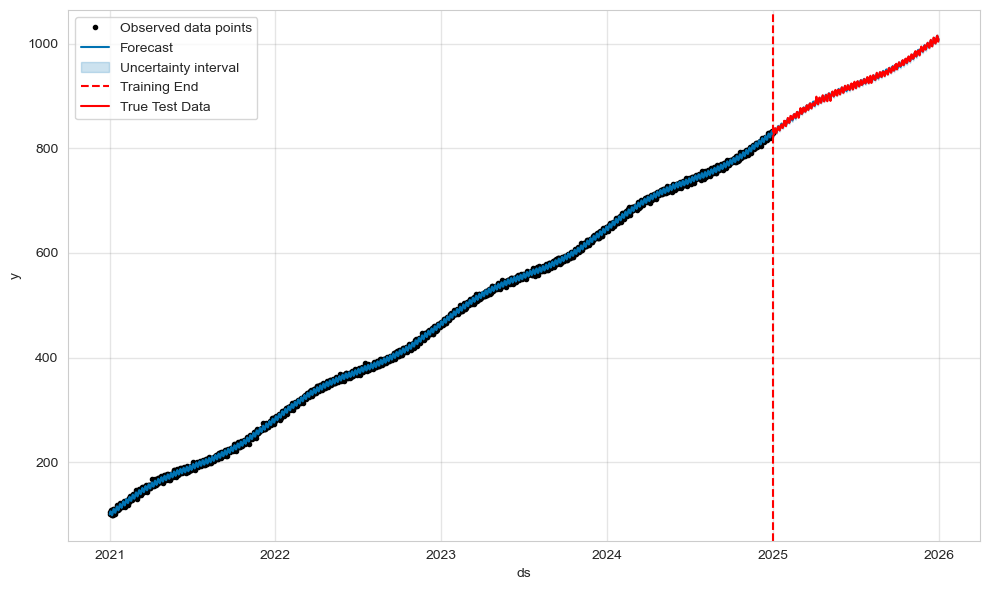

In [41]:
# 5. Run Prophet cross-validation
model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
model.fit(df_tr)
    
# We specify the forecast horizon (horizon), and then optionally the size of the initial training period (initial)
# and the spacing between cutoff dates (period). By default, the initial training period is set to 
# three times the horizon, and cutoffs are made every half a horizon.
df_cv = cross_validation(model, initial='730 days', period='45 days', horizon = '90 days')
#print(df_cv.to_string())

future_df = model.make_future_dataframe(periods=365, freq='D', include_history=True)
forecast = model.predict(future_df)

# 6. Plot the forecast
# plot the time series 
forecast_plot = model.plot(forecast)

# add a vertical line at the end of the training period
axes = forecast_plot.gca()
axes.axvline(x=end_date, color='red', linestyle='--', label='Training End')

# plot true test data for the period after the red line
plt.plot(df_tst['ds'], df_tst['y'],'r', markersize=3, label='True Test Data')

# show the legend to distinguish between the lines
plt.legend()

# calculate rmse of model

#end_date = pd.to_datetime('2024-12-31')
#mask2 = (df['ds'] > end_date)
future_forecast = forecast.loc[mask2]

rmse = root_mean_squared_error(df_tst['y'], future_forecast['yhat'])
print("RMSE of model with best hyperparams:", rmse)


23:29:24 - cmdstanpy - INFO - Chain [1] start processing
23:29:24 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
23:29:34 - cmdstanpy - INFO - Chain [1] start processing
23:29:34 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
23:29:43 - cmdstanpy - INFO - Chain [1] start processing
23:29:43 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
23:29:52 - cmdstanpy - INFO - Chain [1] start processing
23:29:52 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.
23:30:01 - cmdstanpy - INFO - Chain [1] start processing
23:30:01 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has per

    changepoint_prior_scale  seasonality_prior_scale      rmse
0                     0.001                     0.01  2.064845
1                     0.001                     0.10  2.066651
2                     0.001                     1.00  2.064399
3                     0.001                    10.00  2.064610
4                     0.010                     0.01  2.066448
5                     0.010                     0.10  2.067417
6                     0.010                     1.00  2.067406
7                     0.010                    10.00  2.067457
8                     0.100                     0.01  2.290738
9                     0.100                     0.10  2.184501
10                    0.100                     1.00  2.181628
11                    0.100                    10.00  2.182131
12                    0.500                     0.01  4.969936
13                    0.500                     0.10  3.127525
14                    0.500                     1.00  2

23:32:01 - cmdstanpy - INFO - Chain [1] start processing
23:32:01 - cmdstanpy - INFO - Chain [1] done processing


The optimal hyperparameters are    changepoint_prior_scale  seasonality_prior_scale      rmse
2                    0.001                      1.0  2.064399


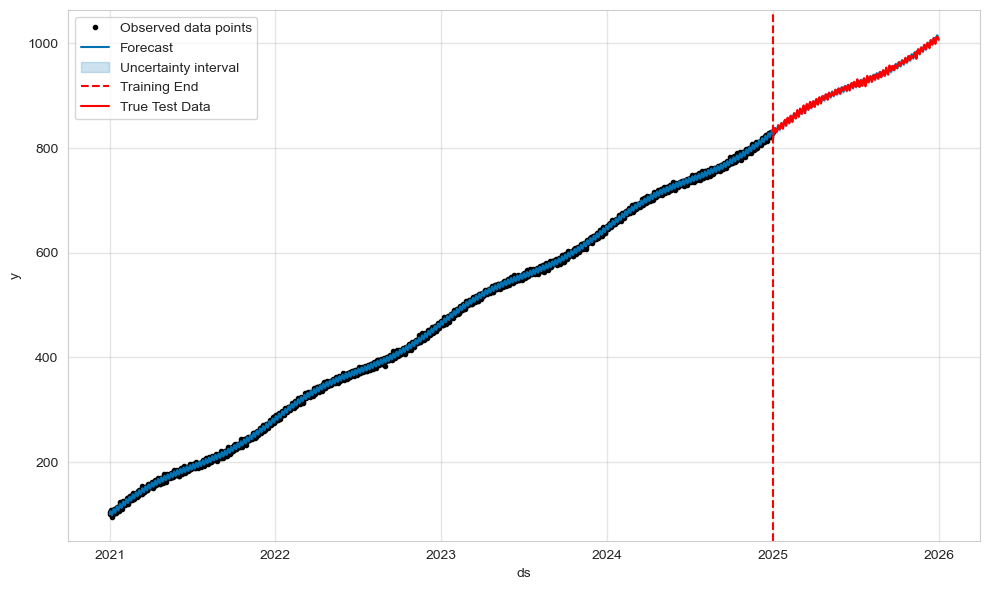

In [ ]:

import itertools
import numpy as np
import pandas as pd

param_grid = {  
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
}

# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
rmses = []  # Store the RMSEs for each params here

# Use cross validation to evaluate all parameters
best_rmse = 5
for params in all_params:
    m = Prophet(**params)
    m.fit(df_tr)  # Fit model with given params
    df_cv = cross_validation(m, initial='365 days', period='45 days', horizon = '90 days', parallel="processes")
    df_p = performance_metrics(df_cv, rolling_window=1)
    rmse = df_p['rmse'].values[0]
    rmses.append(rmse)

# Find the best parameters
tuning_results = pd.DataFrame(all_params)
tuning_results['rmse'] = rmses
print(tuning_results)

# Get params for min rmse in tuning_results. Create Prophet model with these params. Fit test data
best_row = tuning_results[tuning_results['rmse'] == min(rmses)]
best_cps = best_row.iloc[0]['changepoint_prior_scale']
best_sps = best_row.iloc[0]['seasonality_prior_scale']
model = Prophet(changepoint_prior_scale=best_cps, seasonality_prior_scale=best_sps).fit(df_tr)

# Make the forecast
future_df = model.make_future_dataframe(periods=365, freq='D', include_history=True)
forecast = model.predict(future_df)

# Plot the time series 
forecast_plot = model.plot(forecast)

# add a vertical line at the end of the training period
axes = forecast_plot.gca()
axes.axvline(x=end_date, color='red', linestyle='--', label='Training End')

# plot true test data for the period after the red line
plt.plot(df_tst['ds'], df_tst['y'],'r', markersize=3, label='True Test Data')

# show the legend to distinguish between the lines
plt.legend()

print("The optimal hyperparameters are", best_row)

In [40]:
# calculate rmse of optimized model

#end_date = pd.to_datetime('2024-12-31')
#mask2 = (df['ds'] > end_date)
future_forecast = forecast.loc[mask2]

rmse = root_mean_squared_error(df_tst['y'], future_forecast['yhat'])
print("RMSE of model with best hyperparams:", rmse)


RMSE of model with best hyperparams: 1.9273251215895106


### Copied code that got repurposed.

In [ ]:
for col in ["Open", "High", "Low", "Close"]:
    gold_ts[col] = gold_ts[col].str.replace(",", "").astype(float)
gold_ts["Date"] = pd.to_datetime(gold_ts["Date"], format="%m/%d/%Y")

gold_ts = gold_ts.sort_values("Date")

In [ ]:
#In order to add sunshine_duration as a regressor, we need to add it to the dataframe that we're applying Prophet to.
all_weather_df = pd.read_csv('spring-2026-solar-panel-degradation-team-2/notebooks/eda/AM/weather_CSVs/2105_weather.csv')
all_weather_df['date'] = pd.to_datetime(all_weather_df['date'])
sunshine_df = system_df[['date','sunshine_duration']]

system_df = pd.merge(gold_ts, sunshine_df, on = 'date', how = 'inner')


Fit Prophet model. Here, daily and yearly seasonal components are enabled.

In [ ]:
model = Prophet(daily_seasonality=True, yearly_seasonality=True)
model.fit(train)

Forecast future values. Number of days predicted is equal to the size of the test set. The forecast will return columns yhat (predicted value), yhat_lower, yhat_upper.

In [ ]:
future = model.make_future_dataframe(periods=test_size)
forecast = model.predict(future)

Compare forecasted values to actual values, and compute MAPE.

In [ ]:
merged = pd.merge(test, forecast[["ds", "yhat"]], on="ds", how="inner")

if merged.empty:
    print("No overlapping dates between forecast and test set.")
else:
    mape = mean_absolute_percentage_error(merged["y"], merged["yhat"]) * 100
    print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")